<a href="https://colab.research.google.com/github/25041032-Jocelyn/PROBABILIDAD-Y-ESTADISTICA/blob/main/ProyectoFinal/Practica_unidad_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 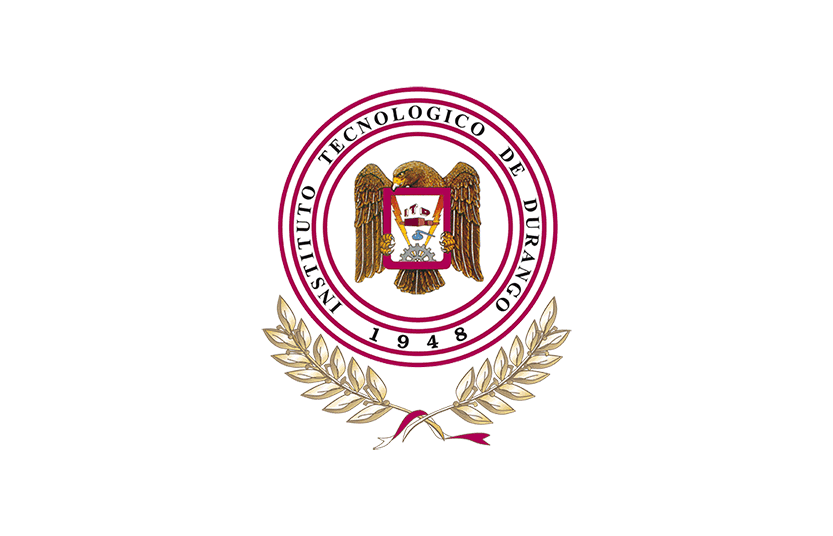

## **Proyecto Final: Análisis Estadístico de Datos COVID-19**
# Materia: Probabilidad y Estadistica
# Grupo: 2YY
# Periodo: Enero-Junio 2026
# 25 de Mayo 2026
# Elaboró: García Castañeda Jocelyn, Montor de Santiago Jordy German
# Facilitador: Jose Gabriel Rodriguez Rivas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import norm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ruta = "/content/drive/MyDrive/covid2020-2021-codificado.csv"

df = pd.read_csv(ruta, low_memory=False)

In [ ]:
df.head()

,SECTOR,SEXO,ENTIDAD_NAC,TIPO_PACIENTE,FECHA_INGRESO,FECHA_DEF,INTUBADO,NEUMONIA,EDAD,EMBARAZO,...,DIABETES,EPOC,ASMA,HIPERTENSION,CARDIOVASCULAR,OBESIDAD,RENAL_CRONICA,TABAQUISMO,RESULTADO_ANTIGENO,UCI
0,Issste,Femenino,San Luis Potosí,Ambulatorio,2020-12-06,9999-99-99,No aplica,No,55,No,...,Si,No,No,No,No,No,No,No,Pendiente,No aplica
1,Issste,Masculino,San Luis Potosí,Ambulatorio,2020-02-20,9999-99-99,No aplica,No,59,No aplica,...,No,No,No,No,No,No,No,No,Pendiente,No aplica
2,Ssa,Femenino,Jalisco,Ambulatorio,2020-04-22,9999-99-99,No aplica,No,42,No,...,No,No,Si,No,No,No,No,No,Pendiente,No aplica
3,Ssa,Masculino,Chihuahua,Ambulatorio,2020-07-28,9999-99-99,No aplica,No,35,No aplica,...,No,No,No,No,No,No,No,No,Pendiente,No aplica
4,Ssa,Masculino,Ciudad De México,Ambulatorio,2020-08-18,9999-99-99,No aplica,No,51,No aplica,...,No,No,No,Si,No,No,No,No,Pendiente,No aplica


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12634194 entries, 0 to 12634193
Data columns (total 21 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   SECTOR              object
 1   SEXO                object
 2   ENTIDAD_NAC         object
 3   TIPO_PACIENTE       object
 4   FECHA_INGRESO       object
 5   FECHA_DEF           object
 6   INTUBADO            object
 7   NEUMONIA            object
 8   EDAD                int64 
 9   EMBARAZO            object
 10  INDIGENA            object
 11  DIABETES            object
 12  EPOC                object
 13  ASMA                object
 14  HIPERTENSION        object
 15  CARDIOVASCULAR      object
 16  OBESIDAD            object
 17  RENAL_CRONICA       object
 18  TABAQUISMO          object
 19  RESULTADO_ANTIGENO  object
 20  UCI                 object
dtypes: int64(1), object(20)
memory usage: 2.0+ GB


In [ ]:
#Estadística Descriptiva
#Asignamos nombre a las columnas del documento
COL_RESULTADO = 'RESULTADO_ANTIGENO'
COL_TIPO = 'TIPO_PACIENTE'
COL_EMBARAZO = 'EMBARAZO'
COL_INDIGENA = 'INDIGENA'


In [ ]:
#Casos por resultado
positivos = int((df[COL_RESULTADO] == 'Positivo').sum())
negativos = int((df[COL_RESULTADO] == 'Negativo').sum())
pendientes = int((df[COL_RESULTADO] == 'Pendiente').sum())

#Tipo de paciente
ambulatorios = int((df[COL_TIPO] == 'Ambulatorio').sum())
hospitalizados = int((df[COL_TIPO] == 'Hospitalizado').sum())

#Embarazadas e indigenas
embarazadas = int((df[COL_EMBARAZO] == 'Si').sum())
indigenas = int((df[COL_INDIGENA] == 'Si').sum())

total = len(df)

print("=" * 50)
print("Estadística Descriptiva")
print("=" * 50)
print(f"Total de registros: {total:>12,}")
print(f"Casos positivos: {positivos:>12,}")
print(f"Casos negativos: {negativos:>12,}")
print(f"Casos pendientes: {pendientes:>12,}")
print("-" * 50)
print(f"Pacientes ambulatorios: {ambulatorios:>12,}")
print(f"Pacientes hospitalizados: {hospitalizados:>12,}")
print("-" * 50)
print(f"Pacientes embarazadas: {embarazadas:>12,}")
print(f"Paceintes indigenas: {indigenas:>12,}")
print("=" * 50)

Estadística Descriptiva
Total de registros:   12,634,194
Casos positivos:    1,774,708
Casos negativos:    5,853,547
Casos pendientes:    5,005,939
--------------------------------------------------
Pacientes ambulatorios:   11,543,303
Pacientes hospitalizados:    1,090,891
--------------------------------------------------
Pacientes embarazadas:      122,583
Paceintes indigenas:       35,240


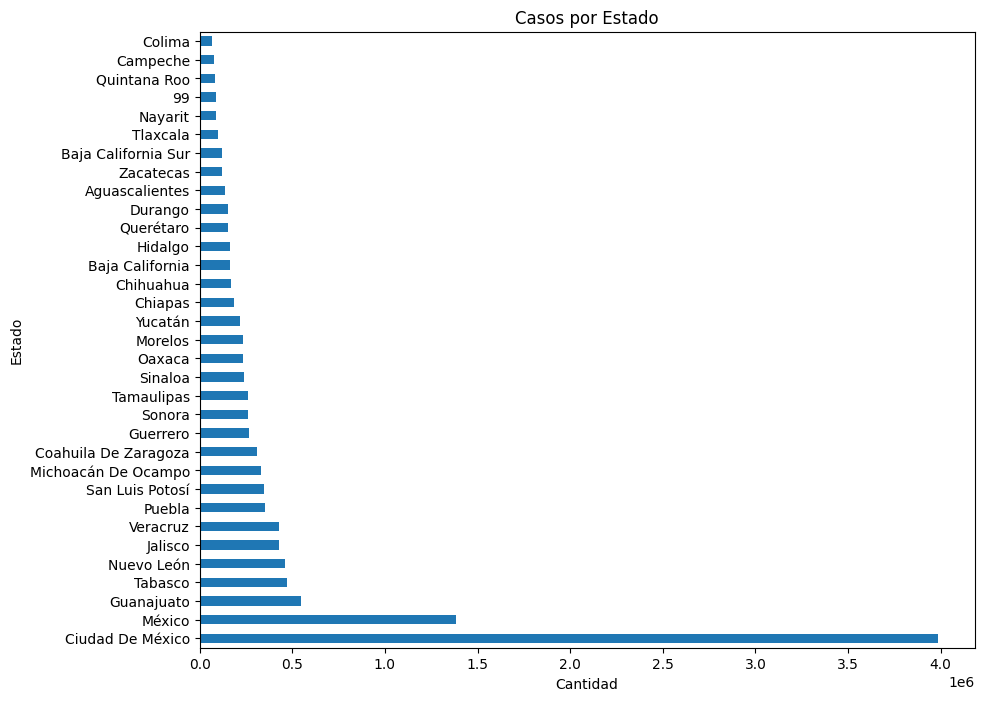

In [ ]:
#Grafico de barras por estados
estado = df['ENTIDAD_NAC'].value_counts()

plt.figure(figsize=(10,8))
estado.plot(kind='barh')

plt.title("Casos por Estado")
plt.xlabel("Cantidad")
plt.ylabel("Estado")

plt.show()

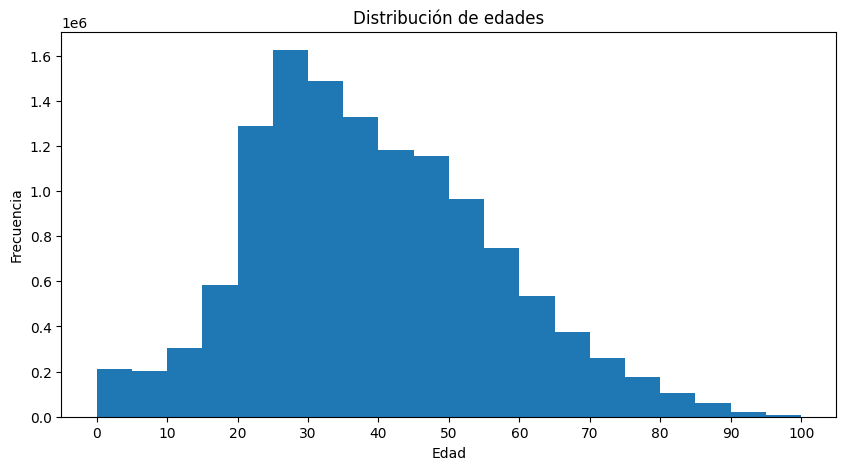

In [ ]:
#Histograma por edad
plt.figure(figsize=(10,5))

plt.hist(df['EDAD'], bins=20, range=(0,100))

plt.xticks(range(0,101,10))
plt.title("Distribución de edades")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.show()

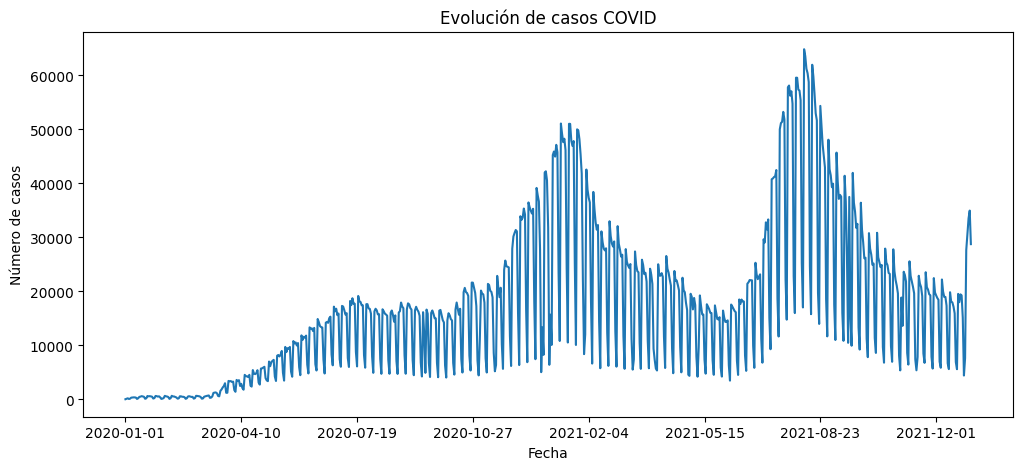

In [ ]:
#Gráfico de líneas por fecha para mostrar la evolución de casos
casos_fecha = df.groupby('FECHA_INGRESO').size()

plt.figure(figsize=(12,5))

casos_fecha.plot()

plt.title("Evolución de casos COVID")
plt.xlabel("Fecha")
plt.ylabel("Número de casos")

plt.show()

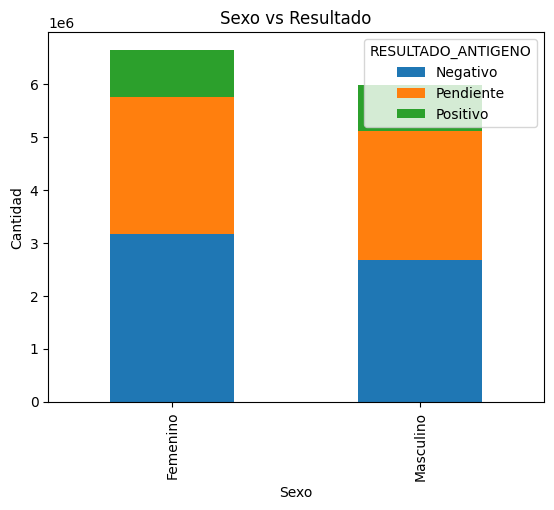

In [ ]:
#Gráfico de barras apiladas por sexo y resultado
tabla = pd.crosstab(df['SEXO'], df['RESULTADO_ANTIGENO'])

tabla.plot(kind='bar', stacked=True)
plt.title("Sexo vs Resultado")
plt.xlabel("Sexo")
plt.ylabel("Cantidad")

plt.show()

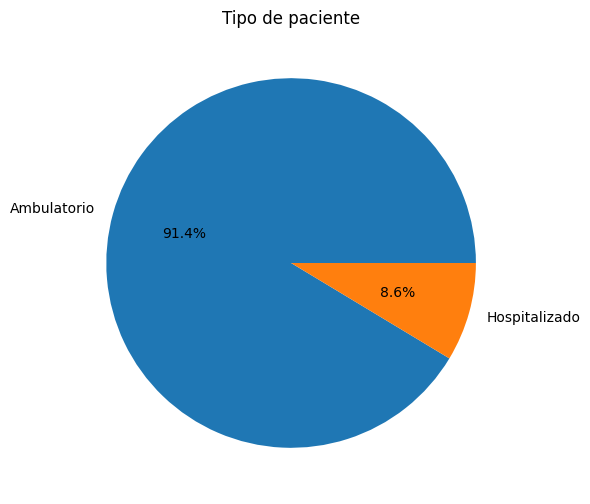

In [ ]:
#Gráfico circular por tipo de paciente
tipos = df['TIPO_PACIENTE'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(tipos, labels=tipos.index, autopct='%1.1f%%')
plt.title("Tipo de paciente")
plt.show()

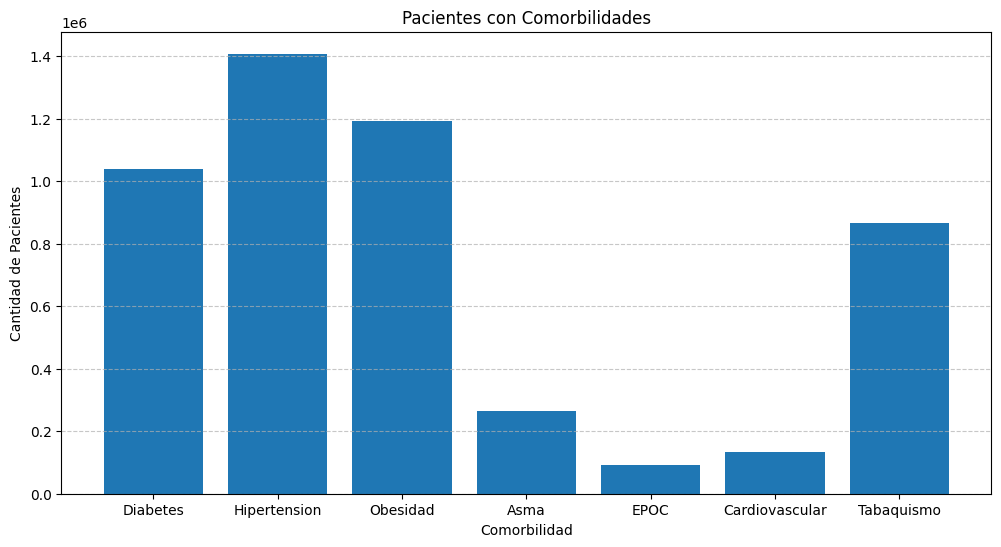

In [ ]:
#Gráfico de barras por comorbilidad
comorbilidades = {
    'Diabetes': (df['DIABETES'] == 'Si').sum(),
    'Hipertension': (df['HIPERTENSION'] == 'Si').sum(),
    'Obesidad': (df['OBESIDAD'] == 'Si').sum(),
    'Asma': (df['ASMA'] == 'Si').sum(),
    'EPOC': (df['EPOC'] == 'Si').sum(),
    'Cardiovascular': (df['CARDIOVASCULAR'] == 'Si').sum(),
    'Tabaquismo': (df['TABAQUISMO'] == 'Si').sum()
}

plt.figure(figsize=(12,6))

plt.bar(comorbilidades.keys(), comorbilidades.values())

plt.title("Pacientes con Comorbilidades")
plt.xlabel("Comorbilidad")
plt.ylabel("Cantidad de Pacientes")

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [ ]:
#Punto 4
#Probabilidad simple de diabetes
total = len(comorbilidades)
prob_diabetes = (df['DIABETES'] == 'Si').sum() / total
print("Probabilidad de pacientes con diabetes:", prob_diabetes)
print("-"*80)
#Probabilidad simple de hipertension
prob_hiper = (df['HIPERTENSION'] == 'Si').sum() / total
print("Probabilidad de pacientes con Hipertension:", prob_hiper)
print("-"*80)
#Probabilidad simple de obesidad
prob_obesidad = (df['OBESIDAD'] == 'Si').sum() / total
print("Probabilidad de pacientes con Obesidad:", prob_obesidad)
print("-"*80)
#Probabilidad simple de EPOC
prob_epoc = (df['EPOC'] == 'Si').sum() / total
print("Probabilidad de pacientes con EPOC:", prob_epoc)
print("-"*80)
#Probabilidad simple de asma
prob_asma = (df['ASMA'] == 'Si').sum() / total
print("Probabilidad de pacientes con ASMA:", prob_asma)
print("-"*80)
#Probabilidad simple de renal cronica
prob_renalcronica = (df['RENAL_CRONICA'] == 'Si').sum() / total
print("Probabilidad de pacientes con Renal Cronica:", prob_renalcronica)
print("-"*80)
#Probabilidad simple de cardiovascular
prob_cardio = (df['CARDIOVASCULAR'] == 'Si').sum() / total
print("Probabilidad de pacientes con Cardiovascular:", prob_cardio)
print("-"*80)
#Probabilidad simple de tabaquismo
prob_tabaco = (df['TABAQUISMO'] == 'Si').sum() / total
print("Probabilidad de pacientes con Tabaquismo:", prob_tabaco)
print("-"*80)

Probabilidad de pacientes con diabetes: 148351.2857142857
--------------------------------------------------------------------------------
Probabilidad de pacientes con Hipertension: 201111.2857142857
--------------------------------------------------------------------------------
Probabilidad de pacientes con Obesidad: 170431.57142857142
--------------------------------------------------------------------------------
Probabilidad de pacientes con EPOC: 13206.57142857143
--------------------------------------------------------------------------------
Probabilidad de pacientes con ASMA: 37693.57142857143
--------------------------------------------------------------------------------
Probabilidad de pacientes con Renal Cronica: 18553.428571428572
--------------------------------------------------------------------------------
Probabilidad de pacientes con Cardiovascular: 19201.428571428572
--------------------------------------------------------------------------------
Probabilidad de p

In [ ]:
#Probabilidad condicional de diabetes en los estados
prob_estado = df.groupby('ENTIDAD_NAC')['DIABETES'].apply(lambda x: (x == 'Si').mean())
print(prob_estado)

ENTIDAD_NAC
99                      0.024336
Aguascalientes          0.075668
Baja California         0.085036
Baja California Sur     0.071792
Campeche                0.087880
Chiapas                 0.082385
Chihuahua               0.105604
Ciudad De México        0.065107
Coahuila De Zaragoza    0.094631
Colima                  0.080198
Durango                 0.091244
Guanajuato              0.092692
Guerrero                0.105741
Hidalgo                 0.119189
Jalisco                 0.108233
Michoacán De Ocampo     0.090339
Morelos                 0.072710
México                  0.066809
Nayarit                 0.095501
Nuevo León              0.091837
Oaxaca                  0.098635
Puebla                  0.107409
Querétaro               0.083779
Quintana Roo            0.045162
San Luis Potosí         0.096841
Sinaloa                 0.100987
Sonora                  0.095567
Tabasco                 0.090377
Tamaulipas              0.110388
Tlaxcala                0.09757

In [ ]:
#Probabilidad condicional de hipertension en los estados
prob_estado = df.groupby('ENTIDAD_NAC')['HIPERTENSION'].apply(lambda x: (x == 'Si').mean())
print(prob_estado)

ENTIDAD_NAC
99                      0.051137
Aguascalientes          0.116701
Baja California         0.142559
Baja California Sur     0.110704
Campeche                0.124905
Chiapas                 0.108598
Chihuahua               0.164451
Ciudad De México        0.086926
Coahuila De Zaragoza    0.125535
Colima                  0.112408
Durango                 0.132695
Guanajuato              0.128609
Guerrero                0.131879
Hidalgo                 0.154934
Jalisco                 0.155838
Michoacán De Ocampo     0.128704
Morelos                 0.089692
México                  0.083615
Nayarit                 0.144406
Nuevo León              0.113048
Oaxaca                  0.121187
Puebla                  0.123751
Querétaro               0.112082
Quintana Roo            0.062464
San Luis Potosí         0.129126
Sinaloa                 0.165591
Sonora                  0.157872
Tabasco                 0.129262
Tamaulipas              0.149190
Tlaxcala                0.11094

In [ ]:
#Probabilidad condicional de obesidad en los estados
prob_estado = df.groupby('ENTIDAD_NAC')['OBESIDAD'].apply(lambda x: (x == 'Si').mean())
print(prob_estado)

ENTIDAD_NAC
99                      0.041635
Aguascalientes          0.104301
Baja California         0.141031
Baja California Sur     0.125715
Campeche                0.136157
Chiapas                 0.092030
Chihuahua               0.120974
Ciudad De México        0.076437
Coahuila De Zaragoza    0.080147
Colima                  0.145558
Durango                 0.095881
Guanajuato              0.118315
Guerrero                0.101377
Hidalgo                 0.118880
Jalisco                 0.126275
Michoacán De Ocampo     0.092959
Morelos                 0.084327
México                  0.075659
Nayarit                 0.125567
Nuevo León              0.098673
Oaxaca                  0.111071
Puebla                  0.103846
Querétaro               0.109429
Quintana Roo            0.080045
San Luis Potosí         0.103449
Sinaloa                 0.139787
Sonora                  0.146502
Tabasco                 0.092702
Tamaulipas              0.121600
Tlaxcala                0.08750

In [ ]:
#Probabilidad condicional de EPOC en los estados
prob_estado = df.groupby('ENTIDAD_NAC')['EPOC'].apply(lambda x: (x == 'Si').mean())
print(prob_estado)

ENTIDAD_NAC
99                      0.003881
Aguascalientes          0.008908
Baja California         0.008029
Baja California Sur     0.003259
Campeche                0.006973
Chiapas                 0.006587
Chihuahua               0.012001
Ciudad De México        0.004702
Coahuila De Zaragoza    0.005462
Colima                  0.006218
Durango                 0.011533
Guanajuato              0.011803
Guerrero                0.008328
Hidalgo                 0.014494
Jalisco                 0.017084
Michoacán De Ocampo     0.013893
Morelos                 0.005309
México                  0.006179
Nayarit                 0.012725
Nuevo León              0.004866
Oaxaca                  0.008069
Puebla                  0.009574
Querétaro               0.006666
Quintana Roo            0.003627
San Luis Potosí         0.010254
Sinaloa                 0.010700
Sonora                  0.007049
Tabasco                 0.003360
Tamaulipas              0.007994
Tlaxcala                0.01066

In [ ]:
#Probabilidad condicional de asma en los estados
prob_estado = df.groupby('ENTIDAD_NAC')['ASMA'].apply(lambda x: (x == 'Si').mean())
print(prob_estado)

ENTIDAD_NAC
99                      0.026893
Aguascalientes          0.025213
Baja California         0.036818
Baja California Sur     0.028926
Campeche                0.026991
Chiapas                 0.021143
Chihuahua               0.031978
Ciudad De México        0.018734
Coahuila De Zaragoza    0.018598
Colima                  0.028572
Durango                 0.022732
Guanajuato              0.017981
Guerrero                0.022185
Hidalgo                 0.014748
Jalisco                 0.036351
Michoacán De Ocampo     0.018722
Morelos                 0.016901
México                  0.014348
Nayarit                 0.030787
Nuevo León              0.021385
Oaxaca                  0.014620
Puebla                  0.013103
Querétaro               0.010834
Quintana Roo            0.025138
San Luis Potosí         0.020863
Sinaloa                 0.028041
Sonora                  0.034149
Tabasco                 0.028093
Tamaulipas              0.027015
Tlaxcala                0.00897

In [ ]:
#Probabilidad condicional de Insuficiencia Renal Cronica en los estados
prob_estado = df.groupby('ENTIDAD_NAC')['RENAL_CRONICA'].apply(lambda x: (x == 'Si').mean())
print(prob_estado)

ENTIDAD_NAC
99                      0.003075
Aguascalientes          0.015654
Baja California         0.009723
Baja California Sur     0.007188
Campeche                0.010401
Chiapas                 0.010859
Chihuahua               0.013877
Ciudad De México        0.005885
Coahuila De Zaragoza    0.011439
Colima                  0.013809
Durango                 0.011212
Guanajuato              0.012340
Guerrero                0.013367
Hidalgo                 0.018130
Jalisco                 0.023314
Michoacán De Ocampo     0.012870
Morelos                 0.009156
México                  0.010085
Nayarit                 0.016209
Nuevo León              0.010603
Oaxaca                  0.012649
Puebla                  0.015258
Querétaro               0.012787
Quintana Roo            0.006275
San Luis Potosí         0.013056
Sinaloa                 0.011997
Sonora                  0.008378
Tabasco                 0.007993
Tamaulipas              0.014695
Tlaxcala                0.01830

In [ ]:
#Probabilidad condicional de condicion cardiovascular en los estados
prob_estado = df.groupby('ENTIDAD_NAC')['CARDIOVASCULAR'].apply(lambda x: (x == 'Si').mean())
print(prob_estado)

ENTIDAD_NAC
99                      0.008661
Aguascalientes          0.012263
Baja California         0.015193
Baja California Sur     0.010464
Campeche                0.010375
Chiapas                 0.010039
Chihuahua               0.018733
Ciudad De México        0.008319
Coahuila De Zaragoza    0.011430
Colima                  0.010260
Durango                 0.012745
Guanajuato              0.010920
Guerrero                0.010605
Hidalgo                 0.015410
Jalisco                 0.018470
Michoacán De Ocampo     0.013993
Morelos                 0.008566
México                  0.008498
Nayarit                 0.014989
Nuevo León              0.011345
Oaxaca                  0.010871
Puebla                  0.013272
Querétaro               0.008754
Quintana Roo            0.005671
San Luis Potosí         0.012056
Sinaloa                 0.017704
Sonora                  0.014663
Tabasco                 0.007363
Tamaulipas              0.014115
Tlaxcala                0.01147

In [ ]:
#Probabilidad condicional de tabaquismo en los estados
prob_estado = df.groupby('ENTIDAD_NAC')['TABAQUISMO'].apply(lambda x: (x == 'Si').mean())
print(prob_estado)

ENTIDAD_NAC
99                      0.048488
Aguascalientes          0.076362
Baja California         0.070610
Baja California Sur     0.055060
Campeche                0.044391
Chiapas                 0.040769
Chihuahua               0.085999
Ciudad De México        0.091373
Coahuila De Zaragoza    0.061108
Colima                  0.061155
Durango                 0.061314
Guanajuato              0.059217
Guerrero                0.045267
Hidalgo                 0.068796
Jalisco                 0.081110
Michoacán De Ocampo     0.059293
Morelos                 0.052347
México                  0.070279
Nayarit                 0.057403
Nuevo León              0.065515
Oaxaca                  0.034992
Puebla                  0.063980
Querétaro               0.072514
Quintana Roo            0.033239
San Luis Potosí         0.053980
Sinaloa                 0.054531
Sonora                  0.060897
Tabasco                 0.018179
Tamaulipas              0.050892
Tlaxcala                0.04551

In [ ]:
#Distribución normal
media = 2360
desv_estandar = 714
a = 2000 #límite inferior
b = 3000 #límite superior

#Estandarización
z_a = (a - media) / desv_estandar
z_b = (b - media) /desv_estandar

#Probabilidad acumulada
prob= norm.cdf(z_b) - norm.cdf(z_a)

print("=" * 50)
print("Distrubución Normal")
print("=" * 50)
print(f"Media = {media:,} casos")
print(f"Desviación Estándar = {desv_estandar:,} casos")
print(f"Intervalo = [{a:,}, {b:,}]")
print("-" * 55)
print(f"Probabilidad acumulada para a = {a:,} = {norm.cdf(z_a):.4f}")
print(f"Probabilidad acumulada para b = {b:,} = {norm.cdf(z_b):.4f}")
print("-" * 55)
print(f"Probabilidad de que un esatdo tenga entre 2000 y 3000 casos positivos = {prob*100:.2f}%")

Distrubución Normal
Media = 2,360 casos
Desviación Estándar = 714 casos
Intervalo = [2,000, 3,000]
-------------------------------------------------------
Probabilidad acumulada para a = 2,000 = 0.3071
Probabilidad acumulada para b = 3,000 = 0.8150
-------------------------------------------------------
Probabilidad de que un esatdo tenga entre 2000 y 3000 casos positivos = 50.79%


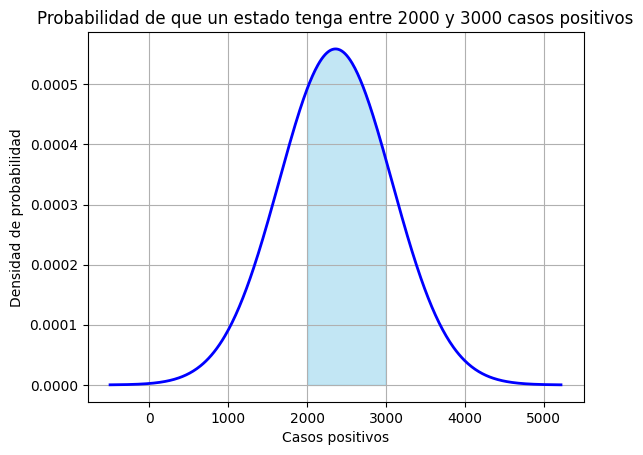

In [ ]:
x = np.linspace(media - 4 * desv_estandar, media + 4 * desv_estandar, 500)
y = norm.pdf(x, loc=media, scale=desv_estandar)

plt.plot(x, y, 'b', linewidth=2)
plt.fill_between(x, y, where=(x >= a) & (x <= b), color='skyblue', alpha=0.5)
plt.title(r"Probabilidad de que un estado tenga entre 2000 y 3000 casos positivos")
plt.xlabel("Casos positivos")
plt.ylabel("Densidad de probabilidad")
plt.grid(True)
plt.show()

#Interpretación General de Resultados
##Distribución de resultados:
El análisis descriptivo reveló la proporción de casos positivos (1,774,708), siendo menor que los negativos (5,853,547), así también como aquellos casos que estan pendientes de diagnostico (5,005,939), lo que nos permite dimensionar el impacto de la pandemia en la poblaciión registrada.
##Tipo de atención:
Por lo que demuestran los datos, la mayoria de los pacientes recibió una atención ambulatoria (91.37%), lo que refleja que una proporción significativa de casos no requirió hospitalización. Esta distrubución refleja que la gran mayoría de los casos no representaron una complicación clínica grave que ametirara internamiento. Sin embargo, el millón de pacientes hospitalizados reoresenta una cifra significativa.
##Casos por estado:
Las gráfica muestran que el mayor numero de contagios registrados en Mexico, le pertenece a la Ciudad de Mexico por una diferencia de mas del doble del siguiente Estado. Esta concentración en Cuidad de México es esperable dado que es la entidad más poblada y con mayor densidad urbana del país, lo que facilita la transmisión del virus.
##Distribución de edades:
El histograma de edades demostró que los grupos de edad más afectados se concentran en adutos de entre 25 a 30 años. A partir de esa edad la frecuencia disminuye de forma progresiva pero sostenida hasta los 100 años. Llama también la atención que existe un número considerable de registros en edades tempranas, cercanas a los 0 años, lo que indica que la enfermedad también afecto a la población infantil.
##Evolución temporal:
La gráfica muestra la evolución diaria de casos en enero 2020 a enero 2022. LOs contagios inician cercanos a cero con un crecimiento gradual durante 2020. Se identifican picos relevantes hacia finales de enero de 2021 y el de mayor longitud en agosto de 2021.
##Sexo vs resultado de Antígeno
La gráfica compara los resultados de pruebas de antígeno entre hombres y mujeres. El gurpo femenino presenta un toral ligeramente mayor, superando los 6.5 millones de registros, frente a aproximadamente 6 millones en el grupo masculino. En ambos sexos predominan los resultados negativos, seguidos de los casos pendientes, mientras que los positivos representan la proporción mpas pequeña.
##Comorbilidades:
La grafica de barras muestra una gran diferencia entre cada una de las distintas situaciones de salud de los pacientes, predominando las personas que presentan hipertension, vemos tambien como se dispersan en los estados algunos dominando mas unos que otros.
##Distrubución normal:
El ejercicio mostró que existe una probabilidad del 50.79% de que un estado registre entre 2,000 y 3,000 casos positivos de Covid-19 bajo los parametros dados.

# CONCLUSIONES PERSONALES
## Montor de Santiago Jordy German
La materia presenta bien la manera de interpretar los datos y poder realizar los analisis de estos, dependiendo de lo que busquemos o requeramos saber, por otro lado el uso de Python usando Google Colab es de mucha ayuda para la interpretacion visual y grafica de los datos, ya que cuenta con la capacidad de mostrar elementos visualmente y tambien libreriass que hacen mucho mas rapido y eficiente el trabajo. En palabras generales es una muy buena herramienta que para lo que es la carrera de Sistemas ayuda mucho saber que podemos usar la programacion para probabilidades y estadisticas usando un lenguaje de trabajo muy util enfocado en esta parte.
##García Castañeda Jocelyn
Durante el desarrollo de esta práctica, manejamos conceptos de la probabilidad y estadística, y no solo verlos como conceptos simples con ejemplos pequeños, sino también desde el punto de vista de la programación, con cantidades de datos enormes. Trabajar con datos reales de más de 12 millones de registros nos permitió entender que los datos no siempre viene limpios ni en el formato que esperamos, sin embargo, estos datos son calculados rápidamente gracias a la programación y las formulas ya conocidas de probabilidad y estadística. Usar Python con pansas y matplotlib me pareció una herramienta muy poderosa, ya que permite procesar grandes volúmenes de datos en segundos y visualizarlos de forma clara. Sin duda la forma en la que llevamos a cabo esta materia me motiva a seguir indagando en las bases de datos, y sobre todo, me deja en claro que una carrera como la nuestra es más indispensable de lo que pensamos hoy en día.